# Data Management 

---

Practical activities to support the theory class on:

- heterogeneous data sources;
- vertical integration and ETL;
- data preparation and cleaning;
- missing values, duplicates, and corrupted data;
- transformation and validation;
- *entity matching* using similarity measures.



In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
import re

DATA = Path("data")
pd.set_option("display.max_columns", 50)


**Practice 1: Data Profiling and Heterogeneity**


**Goal:** identify structural, format, naming, unit, and type heterogeneity.

Load `sensor_graz.csv` and `sensor_madrid.json`. Inspect:

- column names;
- data types;
- timestamp formats;
- temperature and battery units;
- impossible or suspicious values.


In [23]:
graz = pd.read_csv(DATA / "sensor_graz.csv")
madrid = pd.read_json(DATA / "sensor_madrid.json")

display(graz.head())
display(madrid.head())


,timestamp,sensor_id,temperature_c,humidity_pct,battery_pct,location
0,2026-05-01 08:00:00,GRZ-01,17.7,53.9,60,Graz
1,2026-05-01 08:05:00,GRZ-02,16.2,35.9,49,Graz
2,2026-05-01 08:10:00,GRZ-02,16.2,51.0,26,Graz
3,2026-05-01 08:15:00,GRZ-01,19.4,49.7,83,Graz
4,2026-05-01 08:20:00,GRZ-01,19.6,43.8,50,Graz


,time_unix,device,temp_f,rh,battery_v,site
0,1777622400,MAD_1,61.6,57.9,3.40,Madrid
1,1777622700,MAD_1,73.3,40.6,3.76,Madrid
2,1777623000,MAD-02,77.6,56.3,3.68,Madrid
3,1777623300,MAD_1,61.3,48.5,3.82,Madrid
4,1777623600,MAD_1,64.5,59.4,3.86,Madrid


In [24]:
profile = pd.DataFrame({
    "file": ["sensor_graz.csv", "sensor_madrid.json"],
    "rows": [len(graz), len(madrid)],
    "columns": [graz.shape[1], madrid.shape[1]],
    "column_names": [list(graz.columns), list(madrid.columns)],
    "data_types": [
        graz.dtypes.astype(str).to_dict(),
        madrid.dtypes.astype(str).to_dict()
    ]
})
display(profile)


,file,rows,columns,column_names,data_types
0,sensor_graz.csv,73,6,"[timestamp, sensor_id, temperature_c, humidity...","{'timestamp': 'object', 'sensor_id': 'object',..."
1,sensor_madrid.json,72,6,"[time_unix, device, temp_f, rh, battery_v, site]","{'time_unix': 'int64', 'device': 'object', 'te..."


**Reference interpretation:** the sources differ in attribute names, timestamp format, temperature units, battery representation, identifiers, and physical file format. They require mapping and transformation before integration.

**Practice 2: ETL Pipeline**


**Goal:** implement a small **Extract–Transform–Load**.

Expected transformations:

- convert both timestamps to `datetime`;
- convert Fahrenheit to Celsius;
- transform battery voltage into an approximate percentage;
- rename columns to a common schema;
- add a `source`;
- concatenate both sources;
- save the result as `data/integrated.csv`.


In [25]:
graz_t = graz.rename(columns={
    "temperature_c": "temperature_c",
    "humidity_pct": "humidity_pct",
    "battery_pct": "battery_pct"
}).copy()
graz_t["timestamp"] = pd.to_datetime(graz_t["timestamp"], errors="coerce")
graz_t["source"] = "graz_csv"
graz_t = graz_t[["timestamp", "sensor_id", "temperature_c",
                 "humidity_pct", "battery_pct", "location", "source"]]


In [26]:
madrid_t = madrid.rename(columns={
    "device": "sensor_id",
    "rh": "humidity_pct",
    "site": "location"
}).copy()
madrid_t["timestamp"] = pd.to_datetime(madrid_t["time_unix"], unit="s", errors="coerce")
madrid_t["temperature_c"] = (madrid_t["temp_f"] - 32) * 5 / 9
madrid_t["battery_pct"] = ((madrid_t["battery_v"] - 3.3) / (4.2 - 3.3) * 100).clip(0, 100)
madrid_t["source"] = "madrid_json"
madrid_t = madrid_t[["timestamp", "sensor_id", "temperature_c",
                     "humidity_pct", "battery_pct", "location", "source"]]


In [27]:
integrated = pd.concat([graz_t, madrid_t], ignore_index=True)
integrated = integrated.sort_values("timestamp").reset_index(drop=True)
integrated.to_csv(DATA / "integrated.csv", index=False)

display(integrated.head())
print("Dataset shape:", integrated.shape)


,timestamp,sensor_id,temperature_c,humidity_pct,battery_pct,location,source
0,2026-05-01 08:00:00,GRZ-01,17.700000,53.9,60.000000,Graz,graz_csv
1,2026-05-01 08:00:00,MAD_1,16.444444,57.9,11.111111,Madrid,madrid_json
2,2026-05-01 08:05:00,MAD_1,22.944444,40.6,51.111111,Madrid,madrid_json
3,2026-05-01 08:05:00,GRZ-02,16.200000,35.9,49.000000,Graz,graz_csv
4,2026-05-01 08:10:00,GRZ-02,16.200000,51.0,26.000000,Graz,graz_csv


Dataset shape: (145, 7)


**Practice 3: Cleaning and Quality Rules**


**Goal:** detect duplicates, missing values, typos, and out-of-range values.

Suggested rules:

- valid temperature: `-40 <= temperature_c <= 60`;
- valid humidity: `0 <= humidity_pct <= 100`;
- valid battery: `0 <= battery_pct <= 100`;
- allowed location: `Graz`, `Madrid`;
- one unique observation per `timestamp + sensor_id`.


In [28]:
corrupted = pd.read_csv(DATA / "corrupted_data.csv")
display(corrupted)

failures = {
    "missing_timestamp": corrupted["timestamp"].isna(),
    "battery_out_of_range": ~corrupted["battery_status"].between(0, 100),
    "temperature_out_of_range": ~corrupted["temperature"].between(-40, 60),
    "humidity_invalid_or_missing": ~corrupted["humidity"].between(0, 100),
    "invalid_location": ~corrupted["location"].isin(["Graz", "Madrid"])
}


,timestamp,name,battery_status,temperature,humidity,location
0,13:12:00.12,Thing_One,30,12,42.00,Graz
1,13:27:00.15,Thing_2,120,13,9999.99,Madring
2,13:12:00.12,Thing_1,30,-500,42.00,Graz
3,NaN,Thing_3,75,21,NaN,Madrid
4,14:01:05.00,thing-2,80,22,51.00,Madrid


In [29]:
quality_report = pd.DataFrame([
    {
        "rule": rule_name,
        "failure_count": int(mask.sum()),
        "failure_percentage": round(mask.mean() * 100, 1)
    }
    for rule_name, mask in failures.items()
])
display(quality_report)


,rule,failure_count,failure_percentage
0,missing_timestamp,1,20.0
1,battery_out_of_range,1,20.0
2,temperature_out_of_range,1,20.0
3,humidity_invalid_or_missing,2,40.0
4,invalid_location,1,20.0


In [30]:
cleaned = corrupted.copy()

cleaned["normalized_name"] = (
    cleaned["name"]
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace("thing_one", "thing_1", regex=False)
)

cleaned["location"] = cleaned["location"].replace({"Madring": "Madrid"})

cleaned.loc[
    ~cleaned["battery_status"].between(0, 100),
    "battery_status"
] = np.nan

cleaned.loc[
    ~cleaned["temperature"].between(-40, 60),
    "temperature"
] = np.nan

cleaned.loc[
    ~cleaned["humidity"].between(0, 100),
    "humidity"
] = np.nan

cleaned = cleaned.drop_duplicates(
    subset=["timestamp", "normalized_name"],
    keep="first"
)

display(cleaned)


,timestamp,name,battery_status,temperature,humidity,location,normalized_name
0,13:12:00.12,Thing_One,30.0,12.0,42.0,Graz,thing_1
1,13:27:00.15,Thing_2,NaN,13.0,NaN,Madrid,thing_2
3,NaN,Thing_3,75.0,21.0,NaN,Madrid,thing_3
4,14:01:05.00,thing-2,80.0,22.0,51.0,Madrid,thing_2


**Practice 4: Missing Values and Time Series**


**Goal:** compare missing-value treatment strategies.

Try at least:

- row deletion;
- median imputation;
- time interpolation by selected_sensor.

Compare the remaining rows and changes in mean, median, and standard deviation.


In [31]:
df = pd.read_csv(DATA / "integrated.csv", parse_dates=["timestamp"])

# First, convert physically impossible values to NaN.
base_clean = df.copy()

base_clean.loc[
    ~base_clean["temperature_c"].between(-40, 60),
    "temperature_c"
] = np.nan

base_clean.loc[
    ~base_clean["humidity_pct"].between(0, 100),
    "humidity_pct"
] = np.nan

deletion = base_clean.dropna(
    subset=["temperature_c", "humidity_pct"]
)

median_imputation = base_clean.copy()
for column in ["temperature_c", "humidity_pct"]:
    median_imputation[column] = (
        median_imputation
        .groupby("sensor_id")[column]
        .transform(lambda series: series.fillna(series.median()))
    )

interpolation = (
    base_clean
    .sort_values(["sensor_id", "timestamp"])
    .set_index("timestamp")
)

for column in ["temperature_c", "humidity_pct"]:
    interpolation[column] = (
        interpolation
        .groupby("sensor_id")[column]
        .transform(
            lambda series: series.interpolate(
                method="time",
                limit_direction="both"
            )
        )
    )

interpolation = interpolation.reset_index()


In [32]:
comparison = pd.DataFrame({
    "strategy": [
        "original",
        "deletion",
        "median imputation",
        "time interpolation"
    ],
    "rows": [
        len(base_clean),
        len(deletion),
        len(median_imputation),
        len(interpolation)
    ],
    "missing_temperature": [
        base_clean["temperature_c"].isna().sum(),
        deletion["temperature_c"].isna().sum(),
        median_imputation["temperature_c"].isna().sum(),
        interpolation["temperature_c"].isna().sum()
    ],
    "temperature_mean": [
        base_clean["temperature_c"].mean(),
        deletion["temperature_c"].mean(),
        median_imputation["temperature_c"].mean(),
        interpolation["temperature_c"].mean()
    ],
    "temperature_std": [
        base_clean["temperature_c"].std(),
        deletion["temperature_c"].std(),
        median_imputation["temperature_c"].std(),
        interpolation["temperature_c"].std()
    ]
})

display(comparison)


,strategy,rows,missing_temperature,temperature_mean,temperature_std
0,original,145,3,18.467997,2.069541
1,deletion,140,0,18.454683,2.081299
2,median imputation,145,0,18.457739,2.050795
3,time interpolation,145,0,18.470322,2.050639


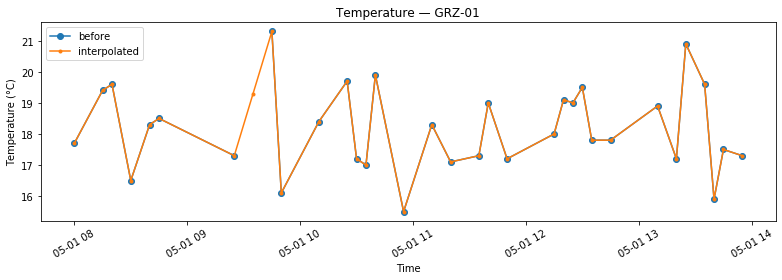

In [33]:
selected_sensor = interpolation["sensor_id"].iloc[0]

before = (
    base_clean[base_clean["sensor_id"] == selected_sensor]
    .sort_values("timestamp")
)

after = (
    interpolation[interpolation["sensor_id"] == selected_sensor]
    .sort_values("timestamp")
)

plt.figure(figsize=(11, 4))
plt.plot(
    before["timestamp"],
    before["temperature_c"],
    marker="o",
    label="before"
)
plt.plot(
    after["timestamp"],
    after["temperature_c"],
    marker=".",
    label="interpolated"
)
plt.title(f"Temperature — {selected_sensor}")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Practice 5: Integration by Keys and Time**


**Goal:** enrich measurements with metadata and align time series.

Use the station catalog and try:

- exact join by identifier;
- identifier normalization;
- `merge_asof` to associate temporally close observations;
- explain when an exact join causes record loss.


In [34]:
catalog = pd.read_csv(DATA / "station_catalog_a.csv")
df = pd.read_csv(DATA / "integrated.csv", parse_dates=["timestamp"])

exact_merge = df.merge(
    catalog,
    left_on="sensor_id",
    right_on="station_id",
    how="left"
)

print(
    "Records without metadata:",
    exact_merge["station_id"].isna().sum()
)
display(exact_merge.head())


Records without metadata: 36


,timestamp,sensor_id,temperature_c,humidity_pct,battery_pct,location,source,station_id,name,lat,lon
0,2026-05-01 08:00:00,GRZ-01,17.700000,53.9,60.000000,Graz,graz_csv,GRZ-01,Graz Center,47.0707,15.4395
1,2026-05-01 08:00:00,MAD_1,16.444444,57.9,11.111111,Madrid,madrid_json,NaN,NaN,NaN,NaN
2,2026-05-01 08:05:00,MAD_1,22.944444,40.6,51.111111,Madrid,madrid_json,NaN,NaN,NaN,NaN
3,2026-05-01 08:05:00,GRZ-02,16.200000,35.9,49.000000,Graz,graz_csv,GRZ-02,Graz North,47.0950,15.4300
4,2026-05-01 08:10:00,GRZ-02,16.200000,51.0,26.000000,Graz,graz_csv,GRZ-02,Graz North,47.0950,15.4300


In [35]:
def normalize_id(value):
    value = str(value).upper()
    value = re.sub(r"[^A-Z0-9]", "", value)
    value = value.replace("GRAZ", "GRZ")
    return value

df_normalized = df.assign(
    normalized_id=df["sensor_id"].map(normalize_id)
)

catalog_normalized = catalog.assign(
    normalized_id=catalog["station_id"].map(normalize_id)
)

normalized_merge = df_normalized.merge(
    catalog_normalized,
    on="normalized_id",
    how="left",
    suffixes=("", "_catalog")
)

print(
    "Records without metadata after normalization:",
    normalized_merge["station_id"].isna().sum()
)


Records without metadata after normalization: 36


In [36]:
# Example of temporal alignment.
left = (
    df[["timestamp", "sensor_id", "temperature_c"]]
    .sort_values("timestamp")
)

right = (
    df[["timestamp", "sensor_id", "humidity_pct"]]
    .assign(
        timestamp=lambda frame:
        frame["timestamp"] + pd.Timedelta(minutes=2)
    )
    .sort_values("timestamp")
)

aligned = pd.merge_asof(
    left,
    right,
    on="timestamp",
    by="sensor_id",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=3),
    suffixes=("_temperature", "_humidity")
)

display(aligned.head())


,timestamp,sensor_id,temperature_c,humidity_pct
0,2026-05-01 08:00:00,GRZ-01,17.700000,53.9
1,2026-05-01 08:00:00,MAD_1,16.444444,57.9
2,2026-05-01 08:05:00,MAD_1,22.944444,40.6
3,2026-05-01 08:05:00,GRZ-02,16.200000,35.9
4,2026-05-01 08:10:00,GRZ-02,16.200000,51.0


**Practice 6: Entity matching**


**Goal:** find records that represent the same station even when names or identifiers differ.

Use:

- text normalization;
- edit-based similarity;
- approximate geographic distance;
- a combined score and thresholds for `match`, `possible match` and `non-match`.


In [37]:
import re

a = pd.read_csv(DATA / "station_catalog_a.csv")
b = pd.read_csv(DATA / "station_catalog_b.csv")

def norm_text(x):
    x = str(x).lower()
    replacements = {
        "centre": "center", "centro": "center",
        "norte": "north", "wien": "vienna",
        "station": ""
    }
    for old, new in replacements.items():
        x = x.replace(old, new)
    x = re.sub(r"[^a-z0-9]", "", x)
    return x

a["normalized_id"] = a["station_id"].map(norm_text)
a["normalized_name"] = a["name"].map(norm_text)
b["normalized_id"] = b["id"].map(norm_text)
b["normalized_name"] = b["station_name"].map(norm_text)


In [38]:
def similarity(left_value, right_value):
    return SequenceMatcher(
        None,
        str(left_value),
        str(right_value)
    ).ratio()

pairs = (
    a.assign(_key=1)
    .merge(
        b.assign(_key=1),
        on="_key",
        suffixes=("_a", "_b")
    )
    .drop(columns="_key")
)

pairs["identifier_similarity"] = pairs.apply(
    lambda row: similarity(
        row["normalized_id_a"],
        row["normalized_id_b"]
    ),
    axis=1
)

pairs["name_similarity"] = pairs.apply(
    lambda row: similarity(
        row["normalized_name_a"],
        row["normalized_name_b"]
    ),
    axis=1
)

# Approximate Euclidean distance in degrees, sufficient for this exercise.
pairs["geographic_distance"] = np.sqrt(
    (pairs["lat"] - pairs["latitude"]) ** 2
    + (pairs["lon"] - pairs["longitude"]) ** 2
)

pairs["geographic_similarity"] = np.exp(
    -pairs["geographic_distance"] / 0.02
)


In [39]:
pairs["score"] = (
    0.35 * pairs["identifier_similarity"] +
    0.40 * pairs["name_similarity"] +
    0.25 * pairs["geographic_similarity"]
)

pairs["decision"] = pd.cut(
    pairs["score"],
    bins=[-np.inf, 0.60, 0.80, np.inf],
    labels=["non-match", "possible match", "match"],
    right=False
)

resultado = pairs.sort_values(["station_id", "score"], ascending=[True, False])
display(resultado[[
    "station_id", "name", "id", "station_name",
    "identifier_similarity", "name_similarity", "geographic_similarity", "score", "decision"
]].head(15))


,station_id,name,id,station_name,identifier_similarity,name_similarity,geographic_similarity,score,decision
0,GRZ-01,Graz Center,GRAZ-1,Graz Centre,0.800000,1.000000,9.929539e-01,0.928238,match
1,GRZ-01,Graz Center,GRZ_02,Graz Norte,0.800000,0.631579,2.697428e-01,0.600067,possible match
2,GRZ-01,Graz Center,MAD1,Madrid Center,0.222222,0.636364,0.000000e+00,0.332323,non-match
3,GRZ-01,Graz Center,MAD-2,Madrid Retiro Station,0.000000,0.363636,0.000000e+00,0.145455,non-match
4,GRZ-01,Graz Center,WIEN-W,Wien West,0.000000,0.300000,1.093193e-32,0.120000,non-match
6,GRZ-02,Graz North,GRZ_02,Graz Norte,1.000000,1.000000,9.859574e-01,0.996489,match
5,GRZ-02,Graz North,GRAZ-1,Graz Centre,0.600000,0.631579,2.695422e-01,0.530017,non-match
8,GRZ-02,Graz North,MAD-2,Madrid Retiro Station,0.222222,0.190476,0.000000e+00,0.153968,non-match
7,GRZ-02,Graz North,MAD1,Madrid Center,0.000000,0.285714,0.000000e+00,0.114286,non-match
9,GRZ-02,Graz North,WIEN-W,Wien West,0.000000,0.210526,2.049592e-32,0.084211,non-match


**Discussion:** thresholds are not universal. They should be calibrated with labeled examples and the cost of false positives and false negatives.